# M07 — Ordinal-Aware Loss

**EEEM068 Applied Machine Learning — MaxViT-Tiny Optimisation Series (M07 of 8)**

This notebook's main methodological contribution: test whether adding a normalised ordinal-distance penalty to M05's loss — so confusing distant grades (e.g. No DR vs Proliferative DR) is penalised far more than confusing adjacent grades (e.g. Mild vs Moderate) — preserves or improves Mild-DR recognition while reducing grade-distance errors and improving or maintaining validation QWK.

This notebook uses the same leakage-free patient-grouped split and the same P0 preprocessing
as the EfficientNet-B4 architecture comparison, so results stay comparable across
architectures. **The internal test set is not loaded or evaluated anywhere in this
notebook** — only validation results are produced here; the test set stays locked until a
final configuration is selected across M01-M08.

## 2. Hypothesis and change from predecessor

M07 is based directly on **M05** (`M05_safe_retinal_augmentation.ipynb`).

M05 is used because it achieved the strongest Mild-aware performance among
M01-M06, with validation QWK 0.7505, macro-F1 0.5596, Mild recall 0.1467
and Mild F1 0.1649.

M07 retains M05's MaxViT-Tiny architecture, clipped class-weighted
cross-entropy, safe retinal augmentation, patient-grouped split, P0
preprocessing, optimiser, scheduler and single-stage fine-tuning protocol.

The only new component is a normalised ordinal-distance penalty added to
the existing weighted cross-entropy loss.

**Question this experiment answers:** Can ordinal supervision preserve or
improve M05's Mild-DR recognition while reducing grade-distance errors and
improving or maintaining validation QWK?

## 3. Imports

In [1]:
import json
import random
from pathlib import Path

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight

print("Imports OK.")

Imports OK.


## 4. Experiment configuration

This section runs immediately after imports and before reproducibility/paths, because
`SEED` is defined here and the reproducibility cell (Section 5) depends on it — running
`set_seed()` before `SEED` exists would raise a `NameError`. `RUN_NAME` and `EXPERIMENT_ID`
are also defined only here, not repeated in the paths cell, so the experiment identifiers can
be updated in one configuration cell when creating the next notebook.

`CLASS_WEIGHT_METHOD`, `CLASS_WEIGHT_CLIP_MIN` and `CLASS_WEIGHT_CLIP_MAX` are set here too, alongside `USE_CLASS_WEIGHTS`/`USE_WRS` — the loss cell (Section 11) reads these values rather than hard-coding its own copy, so the clip range only ever needs to be changed in one place.

The safe-retinal augmentation policy's exact parameters (`HORIZONTAL_FLIP_PROBABILITY`, `ROTATION_DEGREES`, the four `*_JITTER` values, `TRANSLATE_FRACTION`, `SCALE_MIN`/`SCALE_MAX`) are also set here, rather than hard-coded inside the transform (Section 9) — so the exact augmentation policy used is visible in one place and recorded automatically in `config.json`.

In [2]:
EXPERIMENT_ID = "M07"
RUN_NAME = "M07_ordinal_aware_loss"

MODEL_NAME = "maxvit_tiny_tf_224.in1k"
IMAGE_SIZE = 224
NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
SEED = 42

VIT_MEAN = (0.485, 0.456, 0.406)
VIT_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 32
LEARNING_RATE = 5e-05
WEIGHT_DECAY = 0.05

MAX_EPOCHS = 25
WARMUP_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 7

LABEL_SMOOTHING = 0.0
GRAD_CLIP = 1.0
QWK_TOLERANCE = 1e-4
NUM_WORKERS = 4
TRAINING_MODE = "single_stage"
EXPERIMENT_TYPE = "ordinal_loss_ablation"

ORDINAL_PENALTY_WEIGHT = 0.5

USE_CLASS_WEIGHTS = True
USE_WRS = False
CLASS_WEIGHT_METHOD = "balanced"
CLASS_WEIGHT_CLIP_MIN = 0.5
CLASS_WEIGHT_CLIP_MAX = 2.5

HORIZONTAL_FLIP_PROBABILITY = 0.5
ROTATION_DEGREES = 7
BRIGHTNESS_JITTER = 0.05
CONTRAST_JITTER = 0.05
SATURATION_JITTER = 0.02
HUE_JITTER = 0.0
TRANSLATE_FRACTION = 0.02
SCALE_MIN = 0.98
SCALE_MAX = 1.02

print(f"Experiment : {EXPERIMENT_ID} / {RUN_NAME}")
print(f"LR={LEARNING_RATE}  WD={WEIGHT_DECAY}  BATCH={BATCH_SIZE}  "
      f"MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={EARLY_STOPPING_PATIENCE}")

Experiment : M07 / M07_ordinal_aware_loss
LR=5e-05  WD=0.05  BATCH=32  MAX_EPOCHS=25  PATIENCE=7


## 5. Reproducibility and device

Full seeding across Python/NumPy/PyTorch/CUDA, a seeded per-worker `DataLoader` RNG, and a
hard failure if no CUDA GPU is available. This must run after Section 4, since `set_seed()`
takes `SEED` as its default argument.

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

if device.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. Do not start this training run on CPU."
    )

Device: cuda
GPU: NVIDIA RTX A4000


## 6. Paths and output directories

Points at the same `configs/splits/` manifests used by the EfficientNet notebooks. This
notebook's own logs, checkpoints and figures are written to a run-specific subfolder (named
from `RUN_NAME`, defined in Section 4) so no other M01-M08 notebook's outputs are ever
overwritten.

In [4]:
PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

SPLITS_DIR = PROJECT_ROOT / "configs" / "splits"

TRAIN_CSV = SPLITS_DIR / "train_split.csv"
VAL_CSV = SPLITS_DIR / "val_split.csv"
# The internal test split is intentionally not loaded anywhere in this
# notebook. It stays locked until a final MaxViT configuration is selected
# across M01-M08.

RUN_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / RUN_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / RUN_NAME
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "maxvit_tiny" / RUN_NAME

for directory in [RUN_LOG_DIR, CHECKPOINT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best.pt"


print(f"Run          : maxvit_tiny/{RUN_NAME}")
print(f"Logs         -> {RUN_LOG_DIR}")
print(f"Checkpoints  -> {CHECKPOINT_DIR}")
print(f"Figures      -> {FIGURE_DIR}")

Run          : maxvit_tiny/M07_ordinal_aware_loss
Logs         -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M07_ordinal_aware_loss
Checkpoints  -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/maxvit_tiny/M07_ordinal_aware_loss
Figures      -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M07_ordinal_aware_loss


## 7. Load patient-grouped CSV files

Only `train_split.csv` and `val_split.csv` are loaded — the internal test split is
intentionally absent from this notebook entirely.

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

required_columns = {"image", "level", "patient_id", "eye", "filepath"}

for split_name, frame in [("train", train_df), ("validation", val_df)]:
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{split_name} is missing columns: {sorted(missing_columns)}"
        )

    missing_files = frame.loc[
        ~frame["filepath"].map(lambda path: Path(path).exists())
    ]
    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains {len(missing_files):,} missing image files."
        )

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")

Train      : 24,586
Validation : 5,270


## 8. Verify zero patient overlap

In [6]:
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])

assert train_patients.isdisjoint(val_patients), (
    "Patient overlap detected between train and validation splits."
)

print(f"Train patients      : {len(train_patients):,}")
print(f"Validation patients : {len(val_patients):,}")
print("Patient overlap check: PASSED (zero overlap)")

Train patients      : 12,293
Validation patients : 2,635
Patient overlap check: PASSED (zero overlap)


## 9. Dataset class and transformations

`DRDataset` applies P0 preprocessing on the fly and returns `(image, label, index)`, so
predictions can be matched back to source rows later. Uses the **safe retinal augmentation** policy: small ±7° rotation, mild colour jitter, small affine jitter, horizontal flip. No vertical flips, no aggressive cropping, no Mixup, no random erasing. Every parameter of this policy is read from the named variables set in Section 4, not hard-coded here. The evaluation transform is
a plain resize + normalise with no augmentation.

In [7]:
def _load_rgb(path: str) -> np.ndarray:
    """Load an image file and return it as an RGB uint8 array."""
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Cannot decode image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    """Crop the uninformative black padding around the retinal disc."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    """Pad an image onto a centred square canvas (no resizing yet)."""
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def preprocess_p0(image_path: str, output_size: int = IMAGE_SIZE) -> np.ndarray:
    """P0: crop black borders, pad to square, resize. Same pipeline used for
    the EfficientNet-B4 architecture comparison, kept identical here so
    architecture comparisons are not confounded by preprocessing differences."""
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    img = _pad_square(img)
    return cv2.resize(img, (output_size, output_size), interpolation=cv2.INTER_AREA)


print(f"P0 preprocessing ready. Output size: {IMAGE_SIZE}x{IMAGE_SIZE}, RGB, uint8.")

P0 preprocessing ready. Output size: 224x224, RGB, uint8.


In [8]:
class DRDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        image = preprocess_p0(row["filepath"])
        image = Image.fromarray(image)

        label = int(row["level"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, index

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(
        p=HORIZONTAL_FLIP_PROBABILITY
    ),
    transforms.RandomAffine(
        degrees=ROTATION_DEGREES,
        translate=(
            TRANSLATE_FRACTION,
            TRANSLATE_FRACTION,
        ),
        scale=(SCALE_MIN, SCALE_MAX),
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0,
    ),
    transforms.ColorJitter(
        brightness=BRIGHTNESS_JITTER,
        contrast=CONTRAST_JITTER,
        saturation=SATURATION_JITTER,
        hue=HUE_JITTER,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=VIT_MEAN,
        std=VIT_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])

train_ds = DRDataset(train_df, transform=train_transform)
val_ds = DRDataset(val_df, transform=eval_transform)

AUGMENTATION_CONFIG = {
    "policy": "safe_retinal_augmentation",
    "resize": [IMAGE_SIZE, IMAGE_SIZE],
    "horizontal_flip_probability": HORIZONTAL_FLIP_PROBABILITY,
    "geometric_transform": "single_random_affine",
    "interpolation": "bilinear",
    "rotation_degrees": ROTATION_DEGREES,
    "brightness_jitter": BRIGHTNESS_JITTER,
    "contrast_jitter": CONTRAST_JITTER,
    "saturation_jitter": SATURATION_JITTER,
    "hue_jitter": HUE_JITTER,
    "translation_fraction": TRANSLATE_FRACTION,
    "scale_min": SCALE_MIN,
    "scale_max": SCALE_MAX,
    "vertical_flip": False,
    "mixup": False,
    "random_erasing": False,
}

print(f"train_ds: {len(train_ds):,} | val_ds: {len(val_ds):,}")

train_ds: 24,586 | val_ds: 5,270


## 10. DataLoaders

M07 retains M05's clipped class-weighted loss and ordinary shuffled training
batches. No WeightedRandomSampler is used.

The validation loader uses `shuffle=False` and receives no augmentation or
balancing. The DataLoader configuration is unchanged from M05.

In [10]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 769 | Val batches: 165


## 11. Class weights and ordinal-aware loss

M07 retains the clipped class-weighted cross-entropy used in M05 and adds a
normalised expected squared grade-distance penalty.

For every possible predicted grade, its squared distance from the true grade
is calculated and weighted by the model's predicted probability for that
grade. The expected distance is then divided by the maximum squared distance
of 16, keeping the ordinal component in the range [0, 1].

This means probability assigned to distant incorrect grades receives a larger
penalty than probability assigned to adjacent grades. Unlike ordinary
cross-entropy, the additional component explicitly represents the ordered
relationship between DR grades.

The ordinal penalty weight is fixed at 0.5 before validation results are
observed. All other loss, class-balancing and training settings remain
identical to M05.

In [11]:
class OrdinalPenalisedLoss(nn.Module):
    """Clipped weighted CE plus normalised expected squared grade distance.

    Diabetic retinopathy grades are ordered (0=No DR ... 4=Proliferative DR), so a
    prediction of grade 4 when the truth is grade 0 is a far more serious mistake
    than predicting grade 1. Ordinary cross-entropy treats every wrong class
    identically regardless of how far it is from the truth.

    The penalty term is the *expected* squared distance under the model's own
    predicted distribution: sum_c P(c) * (c - true_grade)^2, normalised by the
    maximum possible squared distance so it stays in [0, 1]. This is not the same
    as the squared distance of the *expected* grade (mean(P) then square) — that
    quantity can be exactly zero even when every unit of probability mass sits on
    completely wrong classes, e.g. 50%/50% on grades 0 and 4 for a true grade-2
    case has an expected grade of exactly 2, giving zero penalty despite putting
    no probability at all on the correct class. Averaging the squared distance
    *before* taking the expectation avoids that failure mode.
    """
    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        ordinal_weight: float = ORDINAL_PENALTY_WEIGHT,
        class_weights: torch.Tensor = None,
        label_smoothing: float = 0.0,
    ):
        super().__init__()

        self.ordinal_weight = ordinal_weight
        self.num_classes = num_classes
        self.max_squared_distance = float((num_classes - 1) ** 2)

        self.cross_entropy = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=label_smoothing,
        )

        self.register_buffer(
            "grade_values",
            torch.arange(num_classes, dtype=torch.float32),
        )

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = self.cross_entropy(logits, targets)

        probabilities = F.softmax(logits, dim=1)

        target_grades = targets.to(dtype=probabilities.dtype).unsqueeze(1)

        squared_distances = (
            self.grade_values.unsqueeze(0) - target_grades
        ).pow(2)

        # Normalise distances to [0, 1]: adjacent grade = 1/16, maximum
        # 0-to-4 error = 1.
        normalised_distances = squared_distances / self.max_squared_distance

        ordinal_loss = (probabilities * normalised_distances).sum(dim=1).mean()

        return ce_loss + self.ordinal_weight * ordinal_loss


if USE_CLASS_WEIGHTS:
    raw_weights = compute_class_weight(
        class_weight=CLASS_WEIGHT_METHOD,
        classes=np.arange(NUM_CLASSES),
        y=train_df["level"].to_numpy(),
    )
    clipped_weights = np.clip(raw_weights, CLASS_WEIGHT_CLIP_MIN, CLASS_WEIGHT_CLIP_MAX)
    class_weights = torch.tensor(clipped_weights, dtype=torch.float32, device=device)
else:
    raw_weights = None
    clipped_weights = None
    class_weights = None

criterion = OrdinalPenalisedLoss(
    num_classes=NUM_CLASSES,
    ordinal_weight=ORDINAL_PENALTY_WEIGHT,
    class_weights=class_weights,
    label_smoothing=LABEL_SMOOTHING,
).to(device)
LOSS_FUNCTION_LABEL = (
    "clipped_weighted_ce_plus_normalised_expected_squared_ordinal_penalty"
)

print(
    "Loss: clipped weighted CE + "
    f"{ORDINAL_PENALTY_WEIGHT} x normalised ordinal penalty"
)
print("Raw balanced weights:", np.round(raw_weights, 3))
print("Clipped weights:", np.round(clipped_weights, 3))
print("Use class weights:", USE_CLASS_WEIGHTS)
print("Use WRS:", USE_WRS)
print("Label smoothing:", LABEL_SMOOTHING)

Loss: clipped weighted CE + 0.5 x normalised ordinal penalty
Raw balanced weights: [0.272 2.877 1.33  8.061 9.699]
Clipped weights: [0.5  2.5  1.33 2.5  2.5 ]
Use class weights: True
Use WRS: False
Label smoothing: 0.0


## 12. MaxViT-Tiny model

The same pretrained `maxvit_tiny_tf_224.in1k` architecture used in M05 is
retained and configured for five DR grades.

M07 uses the same single-stage full-model fine-tuning strategy as M05. The
architecture and training scope are therefore unchanged, ensuring that the
ordinal loss component is the only experimental difference between M05 and
M07.

In [12]:
def build_model(pretrained: bool = True) -> nn.Module:
    """Build MaxViT-Tiny with timm's native num_classes head."""
    return timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=NUM_CLASSES,
    ).to(device)


model = build_model(pretrained=True)

total_parameters = sum(p.numel() for p in model.parameters())

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_parameters:,}")

Model: maxvit_tiny_tf_224.in1k
Total parameters: 30,406,093


## 13. Optimiser and scheduler

`AdamW` with a 3-epoch linear warm-up (`start_factor=0.1 -> 1.0`) followed by
`CosineAnnealingLR` for the remaining epochs, chained with `SequentialLR`. Warm-up matters
more for a pretrained model with attention layers than for a pure CNN: a large learning rate
applied immediately to a freshly-loaded backbone can quickly destroy useful pretrained
attention patterns before the model has had a chance to adapt gently — relevant here since
MaxViT's blocks include attention alongside its convolutional MBConv stages.

In [13]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

warmup_scheduler = LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS,
)
cosine_scheduler = CosineAnnealingLR(
    optimizer, T_max=max(1, MAX_EPOCHS - WARMUP_EPOCHS),
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS],
)

SCHEDULER_CONFIG = {
    "name": "SequentialLR",
    "warmup_scheduler": "LinearLR",
    "warmup_start_factor": 0.1,
    "warmup_end_factor": 1.0,
    "warmup_epochs": WARMUP_EPOCHS,
    "main_scheduler": "CosineAnnealingLR",
}

print(f"Optimizer: AdamW(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: {WARMUP_EPOCHS}-epoch linear warm-up -> CosineAnnealingLR")

Optimizer: AdamW(lr=5e-05, weight_decay=0.05)
Scheduler: 3-epoch linear warm-up -> CosineAnnealingLR


## 14. Training and validation functions

`run_epoch()` disables gradient tracking entirely during evaluation, raises if a training
call is made without an optimizer, guards against an empty loader, and raises if QWK comes
back non-finite. This notebook is single-stage full fine-tuning, so there is no frozen-backbone phase and no BatchNorm-freeze subtlety to handle here — that mechanism was evaluated separately in the two-phase M06 experiment. `checkpoint_improved()` implements the agreed selection rule
exactly: **validation QWK primary** (must improve by more than `QWK_TOLERANCE`),
**validation macro-F1 as tie-break** when QWK is within tolerance of the current best.

In [14]:
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def run_epoch(
    model: nn.Module,
    loader,
    optimizer=None,
    train_mode: bool = True,
    grad_clip: float = GRAD_CLIP,
):
    """Run one complete training or evaluation epoch.

    This notebook is single-stage full fine-tuning, so there is no frozen-backbone
    phase and therefore no BatchNorm-freeze subtlety to handle here (that only
    matters once part of the model is frozen with requires_grad=False, which does
    not happen in this notebook) - see M06 for the head-only two-phase variant
    of this function.
    """

    if train_mode and optimizer is None:
        raise ValueError("An optimizer must be supplied during training.")

    model.train() if train_mode else model.eval()

    total_loss = 0.0
    total_samples = 0
    all_labels, all_preds, all_probs, all_indices = [], [], [], []

    description = "train" if train_mode else "eval"

    for images, labels, indices in tqdm(loader, leave=False, desc=description):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

        if train_mode:
            scaler.scale(loss).backward()
            if grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

        probabilities = F.softmax(logits.detach(), dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.extend(probabilities.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.detach().cpu().tolist())
        all_probs.extend(probabilities.cpu().tolist())
        all_indices.extend(indices.cpu().tolist())

    if total_samples == 0:
        raise RuntimeError("The DataLoader produced no samples.")

    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    if not np.isfinite(epoch_qwk):
        raise RuntimeError("QWK became NaN or infinity during the epoch.")

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "qwk": epoch_qwk,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "indices": all_indices,
    }


def checkpoint_improved(
    val_qwk: float,
    val_macro_f1: float,
    best_qwk: float,
    best_macro_f1: float,
    tolerance: float = QWK_TOLERANCE,
) -> bool:
    """Validation QWK primary, validation macro-F1 tie-break."""
    if val_qwk > best_qwk + tolerance:
        return True
    if abs(val_qwk - best_qwk) <= tolerance and val_macro_f1 > best_macro_f1:
        return True
    return False

## 15. Early-stopping training loop

Checkpoint selection uses `checkpoint_improved()` (Section 14) on every epoch: validation QWK
primary, validation macro-F1 tie-break. `training_history.csv` is re-saved after every epoch,
not just at the end, so an interrupted run never loses its log.

In [15]:
history = []
best_qwk = -1.0
best_macro_f1 = -1.0
patience_left = EARLY_STOPPING_PATIENCE

print("=" * 60)
print(f"  {RUN_NAME}")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8}")
print("-" * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    lr_used = optimizer.param_groups[0]["lr"]

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer, train_mode=True)
    val_metrics = run_epoch(model, val_loader, train_mode=False)
    scheduler.step()

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate": lr_used,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(RUN_LOG_DIR / "training_history.csv", index=False)

    marker = ""
    if checkpoint_improved(val_metrics["qwk"], val_metrics["macro_f1"], best_qwk, best_macro_f1):
        best_qwk = val_metrics["qwk"]
        best_macro_f1 = val_metrics["macro_f1"]
        patience_left = EARLY_STOPPING_PATIENCE
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            BEST_CHECKPOINT_PATH,
        )
        marker = "  [best]"
    else:
        patience_left -= 1

    print(
        f"{epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f}"
        f"{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"\nBest val QWK = {best_qwk:.4f} (macro-F1 = {best_macro_f1:.4f}) -> {BEST_CHECKPOINT_PATH.name}")

  M07_ordinal_aware_loss
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1
------------------------------------------------------------


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

1            1.3663   0.1987     1.2108   0.4220   0.2435  [best]


train:   0%|          | 0/769 [00:00<?, ?it/s]

...

eval:   0%|          | 0/165 [00:00<?, ?it/s]

12           0.2537   0.9161     1.7193   0.7180   0.5297


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

13           0.2072   0.9293     1.8280   0.7071   0.5252
Early stopping at epoch 13.

Best val QWK = 0.7619 (macro-F1 = 0.5519) -> best.pt


## 16. Training curves

Train/validation loss and QWK across every epoch actually run. 

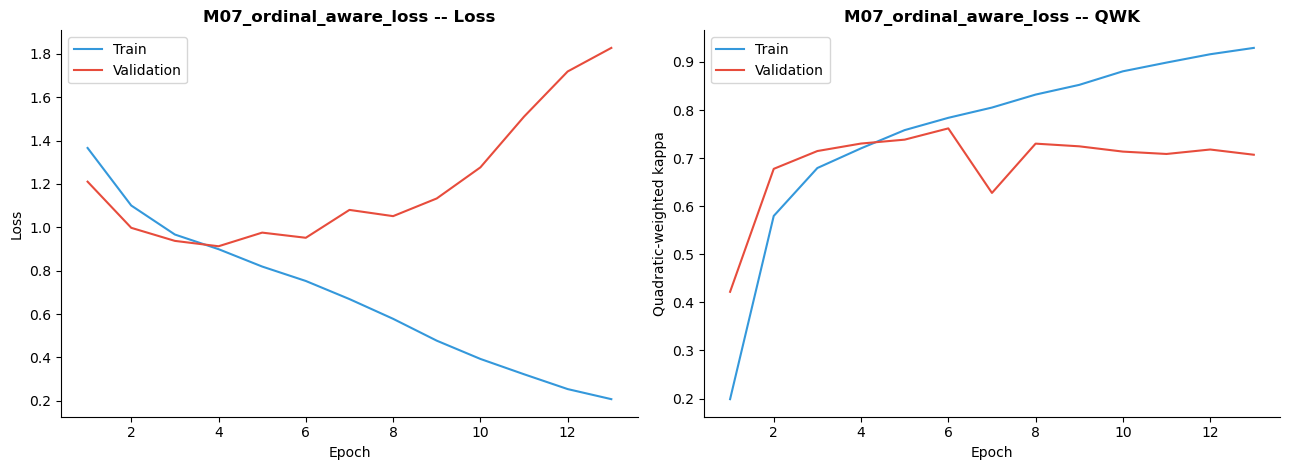

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M07_ordinal_aware_loss/training_curves.png


In [16]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train", color="#3498DB")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation", color="#E74C3C")

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{RUN_NAME} -- Loss", fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(history_df["epoch"], history_df["train_qwk"], label="Train", color="#3498DB")
axes[1].plot(history_df["epoch"], history_df["val_qwk"], label="Validation", color="#E74C3C")

axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Quadratic-weighted kappa")
axes[1].set_title(f"{RUN_NAME} -- QWK", fontweight="bold")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'training_curves.png'}")

## 17. Validation metrics and confusion matrix

The best checkpoint (by validation QWK, macro-F1 tie-break) is reloaded fresh and re-evaluated
on `val_loader` — **not the internal test set** — to get the metrics this notebook actually
reports: QWK, accuracy, balanced accuracy, macro-F1, macro precision/recall, and the full
per-class classification report, plus raw-count and row-normalised confusion matrices.

In [17]:
best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)

eval_model = build_model(pretrained=False)
eval_model.load_state_dict(best_checkpoint["model_state"])

print(f"Loaded: {BEST_CHECKPOINT_PATH.name}")
print(f"epoch={best_checkpoint['epoch']}  val_qwk={best_checkpoint['val_qwk']:.4f}  "
      f"val_macro_f1={best_checkpoint['val_macro_f1']:.4f}")

final_val_metrics = run_epoch(eval_model, val_loader, train_mode=False)

val_macro_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average="macro", zero_division=0,
)
val_macro_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average="macro", zero_division=0,
)

print()
print("=" * 60)
print(f"  {RUN_NAME} -- VALIDATION RESULTS (best checkpoint)")
print("=" * 60)
print(f"  Val QWK               : {final_val_metrics['qwk']:.4f}")
print(f"  Val accuracy           : {final_val_metrics['accuracy']:.4f}")
print(f"  Val balanced accuracy  : {final_val_metrics['balanced_accuracy']:.4f}")
print(f"  Val macro F1           : {final_val_metrics['macro_f1']:.4f}")
print(f"  Val macro precision    : {val_macro_precision:.4f}")
print(f"  Val macro recall       : {val_macro_recall:.4f}")
print()
print(classification_report(
    final_val_metrics["labels"], final_val_metrics["preds"],
    labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES,
    digits=3, zero_division=0,
))

Loaded: best.pt
epoch=6  val_qwk=0.7619  val_macro_f1=0.5519


eval:   0%|          | 0/165 [00:00<?, ?it/s]


  M07_ordinal_aware_loss -- VALIDATION RESULTS (best checkpoint)
  Val QWK               : 0.7619
  Val accuracy           : 0.8034
  Val balanced accuracy  : 0.5507
  Val macro F1           : 0.5519
  Val macro precision    : 0.5670
  Val macro recall       : 0.5507

                  precision    recall  f1-score   support

           No DR      0.872     0.946     0.907      3873
            Mild      0.159     0.101     0.123       368
        Moderate      0.692     0.492     0.576       800
          Severe      0.431     0.567     0.490       127
Proliferative DR      0.680     0.647     0.663       102

        accuracy                          0.803      5270
       macro avg      0.567     0.551     0.552      5270
    weighted avg      0.780     0.803     0.787      5270



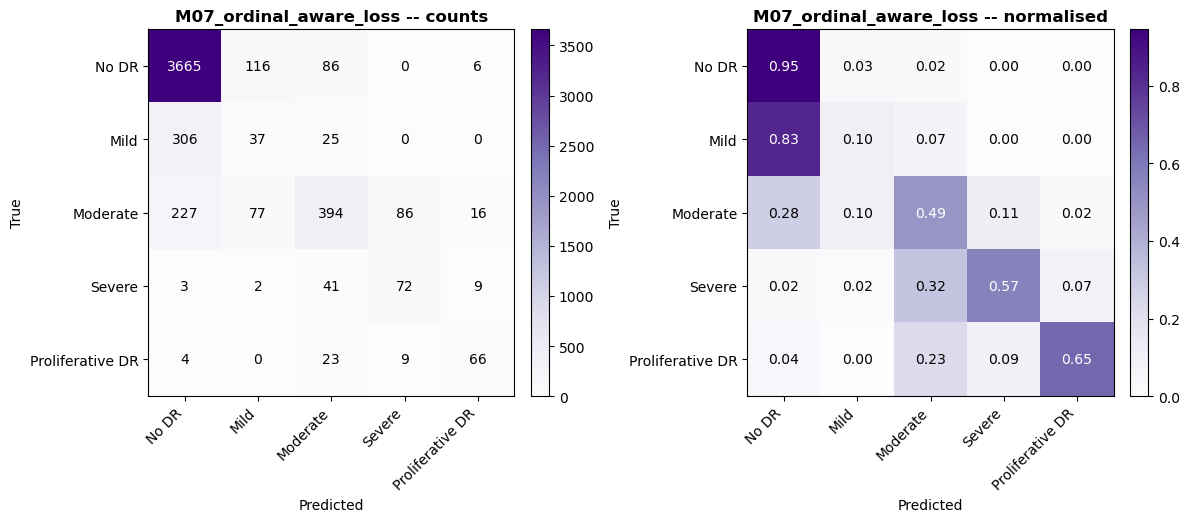

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M07_ordinal_aware_loss/confusion_matrix.png


In [18]:
per_class_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_f1 = f1_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)

cm_counts = confusion_matrix(final_val_metrics["labels"], final_val_metrics["preds"])
cm_normalised = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, data, fmt, title in [
    (axes[0], cm_counts, "d", f"{RUN_NAME} -- counts"),
    (axes[1], cm_normalised, ".2f", f"{RUN_NAME} -- normalised"),
]:
    im = ax.imshow(data, interpolation="nearest", cmap="Purples")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                     color="white" if data[i, j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'confusion_matrix.png'}")

### Mild-DR and ordinal error diagnostics

This notebook deliberately targets Mild-DR recognition while also adding an ordinal-distance
loss component, so both diagnostics are reported together: Mild precision/recall/F1, how
many Mild cases were correctly recognised versus confused with No DR or Moderate, the
overall grade-error profile (mean absolute grade error, within-one-grade accuracy,
adjacent/large-error rates), and the two largest-distance extreme-grade errors specifically
(No DR predicted as Proliferative DR, and vice versa).

In [19]:
labels_array = np.asarray(final_val_metrics["labels"])
preds_array = np.asarray(final_val_metrics["preds"])

grade_error = preds_array - labels_array
absolute_grade_error = np.abs(grade_error)

mild_mask = labels_array == 1

mild_precision = float(per_class_precision[1])
mild_recall = float(per_class_recall[1])
mild_f1 = float(per_class_f1[1])

mild_correct = int(
    np.sum(mild_mask & (preds_array == 1))
)
mild_to_no_dr = int(
    np.sum(mild_mask & (preds_array == 0))
)
mild_to_moderate = int(
    np.sum(mild_mask & (preds_array == 2))
)

mean_absolute_grade_error = float(
    absolute_grade_error.mean()
)
within_one_grade_accuracy = float(
    (absolute_grade_error <= 1).mean()
)
adjacent_grade_error_rate = float(
    (absolute_grade_error == 1).mean()
)
large_grade_error_rate = float(
    (absolute_grade_error > 1).mean()
)

zero_to_four = int(
    np.sum((labels_array == 0) & (preds_array == 4))
)
four_to_zero = int(
    np.sum((labels_array == 4) & (preds_array == 0))
)

ordinal_error_distribution = {
    str(distance): int(
        np.sum(absolute_grade_error == distance)
    )
    for distance in range(NUM_CLASSES)
}

print(f"Mild precision           : {mild_precision:.4f}")
print(f"Mild recall              : {mild_recall:.4f}")
print(f"Mild F1                  : {mild_f1:.4f}")
print(f"Mild correctly predicted : {mild_correct}")
print(f"Mild -> No DR errors     : {mild_to_no_dr}")
print(f"Mild -> Moderate errors  : {mild_to_moderate}")
print(f"Mean absolute grade error: {mean_absolute_grade_error:.4f}")
print(f"Within-one-grade accuracy: {within_one_grade_accuracy:.4f}")
print(f"Adjacent error rate      : {adjacent_grade_error_rate:.4f}")
print(f"Large grade-error rate   : {large_grade_error_rate:.4f}")
print(f"No DR -> PDR errors      : {zero_to_four}")
print(f"PDR -> No DR errors      : {four_to_zero}")

Mild precision           : 0.1595
Mild recall              : 0.1005
Mild F1                  : 0.1233
Mild correctly predicted : 37
Mild -> No DR errors     : 306
Mild -> Moderate errors  : 25
Mean absolute grade error: 0.2706
Within-one-grade accuracy: 0.9304
Adjacent error rate      : 0.1269
Large grade-error rate   : 0.0696
No DR -> PDR errors      : 6
PDR -> No DR errors      : 4


## 18. Save logs and validation predictions

Four artefacts land in `logs/maxvit_tiny/<RUN_NAME>/`: `config.json` (every hyperparameter used),
`best_metrics.json` (the metrics the checkpoint was actually selected on), `validation_metrics.json`
(the full validation metric suite from Section 17), and `validation_predictions.csv` (every
validation image's prediction, matched back to `image`/`patient_id`/`eye`). `training_history.csv`
was already written incrementally during training. A `change_from_m05` entry also records exactly what changed relative to M05 — parameter `loss_function`, its old and new values — directly in this run's own config.json, rather than relying on someone remembering the diff between two notebooks later.

In [20]:
experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "run_name": RUN_NAME,
    "experiment_type": EXPERIMENT_TYPE,
    "predecessor_experiment": "M05_safe_retinal_augmentation",
    "predecessor_reason": "strongest_mild_aware_configuration",
    "primary_metric": "validation_qwk",
    "mild_diagnostic_metric": "validation_mild_f1",
    "ordinal_penalty_type": "normalised_expected_squared_grade_distance",
    "ordinal_penalty_weight": ORDINAL_PENALTY_WEIGHT,

    "model_name": MODEL_NAME,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_epochs": WARMUP_EPOCHS,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_wrs": USE_WRS,
    "label_smoothing": LABEL_SMOOTHING,
    "grad_clip": GRAD_CLIP,
    "qwk_tolerance": QWK_TOLERANCE,
    "selection_metric": "validation_qwk",
    "selection_tiebreak": "validation_macro_f1",
    "training_mode": TRAINING_MODE,
    "preprocessing": "P0",
    "pretrained": True,
    "optimizer": "AdamW",
    "loss_function": LOSS_FUNCTION_LABEL,
    "sampler": "shuffle",
    "scheduler": SCHEDULER_CONFIG,
    "normalisation_mean": list(VIT_MEAN),
    "normalisation_std": list(VIT_STD),
    "training_augmentation": AUGMENTATION_CONFIG,
    "train_class_counts": {
        str(int(label)): int(count)
        for label, count in train_df["level"].value_counts().sort_index().items()
    },
    "total_parameters": total_parameters,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "num_workers": NUM_WORKERS,
    "mixed_precision": use_amp,
    "device": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
}

if USE_CLASS_WEIGHTS:
    experiment_config.update({
        "class_weight_method": CLASS_WEIGHT_METHOD,
        "class_weight_clip_min": CLASS_WEIGHT_CLIP_MIN,
        "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
        "raw_class_weights": raw_weights.tolist(),
        "clipped_class_weights": clipped_weights.tolist(),
    })


experiment_config["change_from_m05"] = {
    "parameter": "loss_function",
    "m05_value": "clipped_class_weighted_cross_entropy",
    "m07_value": LOSS_FUNCTION_LABEL,
    "ordinal_penalty_weight": ORDINAL_PENALTY_WEIGHT,
}

with open(RUN_LOG_DIR / "config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)

best_metrics = {
    "epoch": best_checkpoint["epoch"],
    "val_loss": best_checkpoint["val_loss"],
    "val_accuracy": best_checkpoint["val_accuracy"],
    "val_balanced_accuracy": best_checkpoint["val_balanced_accuracy"],
    "val_macro_f1": best_checkpoint["val_macro_f1"],
    "val_qwk": best_checkpoint["val_qwk"],
}
with open(RUN_LOG_DIR / "best_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=2)

validation_metrics = {
    "qwk": final_val_metrics["qwk"],
    "accuracy": final_val_metrics["accuracy"],
    "balanced_accuracy": final_val_metrics["balanced_accuracy"],
    "macro_f1": final_val_metrics["macro_f1"],
    "macro_precision": val_macro_precision,
    "macro_recall": val_macro_recall,
    "per_class_precision": per_class_precision.tolist(),
    "per_class_recall": per_class_recall.tolist(),
    "per_class_f1": per_class_f1.tolist(),
}
validation_metrics.update({
    "mild_precision": mild_precision,
    "mild_recall": mild_recall,
    "mild_f1": mild_f1,
    "mild_correct": mild_correct,
    "mild_to_no_dr": mild_to_no_dr,
    "mild_to_moderate": mild_to_moderate,
    "mean_absolute_grade_error": mean_absolute_grade_error,
    "within_one_grade_accuracy": within_one_grade_accuracy,
    "adjacent_grade_error_rate": adjacent_grade_error_rate,
    "large_grade_error_rate": large_grade_error_rate,
    "zero_to_four": zero_to_four,
    "four_to_zero": four_to_zero,
    "ordinal_error_distribution": ordinal_error_distribution,
})

with open(RUN_LOG_DIR / "validation_metrics.json", "w") as f:
    json.dump(validation_metrics, f, indent=2)

pred_rows = val_df.iloc[final_val_metrics["indices"]].reset_index(drop=True).copy()
pred_rows["true_label"] = final_val_metrics["labels"]
pred_rows["predicted_label"] = final_val_metrics["preds"]
probs_array = np.array(final_val_metrics["probs"])
for grade in range(NUM_CLASSES):
    pred_rows[f"prob_grade_{grade}"] = probs_array[:, grade]
pred_rows["correct"] = pred_rows["true_label"] == pred_rows["predicted_label"]
pred_rows["grade_error"] = (
    pred_rows["predicted_label"] - pred_rows["true_label"]
)
pred_rows["absolute_grade_error"] = pred_rows["grade_error"].abs()

prediction_columns = [
    "image", "patient_id", "eye", "true_label", "predicted_label",
    "prob_grade_0", "prob_grade_1", "prob_grade_2", "prob_grade_3", "prob_grade_4",
    "correct",
    "grade_error", "absolute_grade_error",
]
pred_rows[prediction_columns].to_csv(RUN_LOG_DIR / "validation_predictions.csv", index=False)

print(f"Saved -> {RUN_LOG_DIR / 'config.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'best_metrics.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'validation_metrics.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'validation_predictions.csv'}  ({len(pred_rows):,} rows)")
print()
print("training_history.csv was already saved incrementally during training.")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M07_ordinal_aware_loss/config.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M07_ordinal_aware_loss/best_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M07_ordinal_aware_loss/validation_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M07_ordinal_aware_loss/validation_predictions.csv  (5,270 rows)

training_history.csv was already saved incrementally during training.


## 19. Experiment conclusion

*To be completed after this notebook has actually been run.*

Compare M07 directly against M05:

- validation QWK, macro-F1, accuracy and balanced accuracy;
- Mild precision, recall and F1;
- Mild-to-No-DR and Mild-to-Moderate errors;
- mean absolute grade error;
- within-one-grade accuracy;
- adjacent-grade and large-grade error rates;
- extreme 0-to-4 and 4-to-0 errors.

M07 should be compared directly with M05 to isolate the contribution of the
ordinal component. Final MaxViT selection must also consider M06, which
currently has the highest validation QWK, while M05 remains the strongest
Mild-aware predecessor.

**Question this experiment answers:** Does adding a normalised ordinal-distance
penalty to M05 preserve or improve Mild-DR recognition while reducing
grade-distance errors and improving or maintaining validation QWK?